/tmp/ipykernel_153/708950927.py:19: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start_date)[0]
/tmp/ipykernel_153/708950927.py:19: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start_date)[0]
/tmp/ipykernel_153/708950927.py:21: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  mom_factor = web.DataReader('F-F_Momentum_Factor', 'famafrench', start_date)[0]
/tmp/ipykernel_153/708950927.py:21: F

ANÁLISIS DE FACTORES PARA AAPL
R-squared CAPM:    0.4290
R-squared FF3:     0.4810
R-squared Carhart: 0.4816


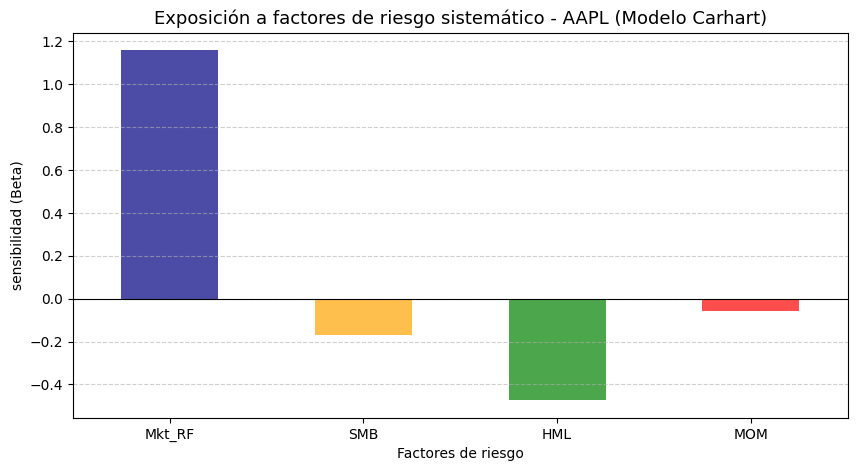


PERFIL DE INVERSIÓN (Basado en betas)
- Perfil: Large-Cap (grandes empresas)
- Estilo: Growth (crecimiento)
- Tendencia: Reversión (perdedor reciente)


In [1]:
#PROYECTO: Asset_Pricing_and_Factors
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Descomposición de retornos y exposición a factores de riesgo sistemático

!pip install -q pandas numpy yfinance statsmodels pandas-datareader matplotlib

import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import pandas_datareader.data as web
import matplotlib.pyplot as plt

#1. EXTRACCIÓN DE FACTORES DE LA LIBRERÍA DE KENNETH FRENCH
#Descargamos los factores FF3 y Momentum (MOM) para el mercado de EE.UU.
start_date = "2015-01-01"

#Factores: Mkt-RF (mercado), SMB (tamaño), HML (valor), RF (tasa libre riesgo)
ff_factors = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start_date)[0]
#Factor momentum: MOM
mom_factor = web.DataReader('F-F_Momentum_Factor', 'famafrench', start_date)[0]

#Unimos y normalizamos (Fama-French publica datos en porcentajes)
factors = ff_factors.join(mom_factor).dropna()
factors /= 100
factors.columns = ['Mkt_RF', 'SMB', 'HML', 'RF', 'MOM']

#2. EXTRACCIÓN DE RETORNOS DEL ACTIVO Apple - AAPL
ticker = "AAPL"
#Usamos el parámetro 'multi_level=False' o seleccionamos directamente la columna para evitar problemas de índices
asset_data = yf.download(ticker, start=start_date, interval='1mo')['Close']
if isinstance(asset_data, pd.DataFrame):
    asset_data = asset_data.dropna().squeeze() # Aseguramos que sea una Serie
else:
    asset_data = asset_data.dropna()

asset_ret = asset_data.pct_change().dropna()

asset_ret.index = asset_ret.index.to_period('M')
asset_ret.name = 'Returns'

#Unimos los dataframes usando el índice
df = pd.concat([asset_ret, factors], axis=1).dropna()
df.columns = ['Returns', 'Mkt_RF', 'SMB', 'HML', 'RF', 'MOM']

#Retorno en exceso del activo (Ri - Rf)
df['Ex_Ret'] = df['Returns'] - df['RF']

#3. ESTIMACIÓN DE MODELOS (CAPM vs FF3 vs CARHART)
def estimate_model(formula_cols, data):
    Y = data['Ex_Ret']
    X = data[formula_cols]
    X = sm.add_constant(X)
    return sm.OLS(Y, X).fit()

#Modelo 1: CAPM (solo mercado)
model_capm = estimate_model(['Mkt_RF'], df)

#Modelo 2: Fama-French 3 factores (market, size, value)
model_ff3 = estimate_model(['Mkt_RF', 'SMB', 'HML'], df)

#Modelo 3: Carhart 4 factores (agrega momentum)
model_carhart = estimate_model(['Mkt_RF', 'SMB', 'HML', 'MOM'], df)

#RESULTADOS Y COMPARACIÓN DE PODER EXPLICATIVO
print(f"ANÁLISIS DE FACTORES PARA {ticker}")
print(f"R-squared CAPM:    {model_capm.rsquared:.4f}")
print(f"R-squared FF3:     {model_ff3.rsquared:.4f}")
print(f"R-squared Carhart: {model_carhart.rsquared:.4f}")

#VISUALIZACIÓN DE EXPOSICIÓN (Betas de los Factores)
#Tomamos los coeficientes del modelo de Carhart para ver la huella digital del activo
betas = model_carhart.params[1:] #omitimos la constante (Alpha)

plt.figure(figsize=(10, 5))
betas.plot(kind='bar', color=['navy', 'orange', 'green', 'red'], alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f"Exposición a factores de riesgo sistemático - {ticker} (Modelo Carhart)", fontsize=13)
plt.ylabel("sensibilidad (Beta)")
plt.xlabel("Factores de riesgo")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#Interpretación rápida del perfil del activo
print("\nPERFIL DE INVERSIÓN (Basado en betas)")
if betas['SMB'] > 0: print("- Perfil: Small-Cap (pymes)")
else: print("- Perfil: Large-Cap (grandes empresas)")

if betas['HML'] > 0: print("- Estilo: Value (subvalorado)")
else: print("- Estilo: Growth (crecimiento)")

if betas['MOM'] > 0: print("- Tendencia: Momentum Positivo (Ganador reciente)")
else: print("- Tendencia: Reversión (perdedor reciente)")